# Capstone Project — Diabetes Risk Prediction
### AI/ML Internship | Weeks 5–6 | Sprint 3: Testing & Refinement (Lab 4)

Prepared by: Syed Muhammad Ali Bokhari

This notebook continues from **Sprint 2** (`Capstone_Sprint2_Modeling_MuhammadAli.ipynb`), which
selected a tuned `RandomForestClassifier` (CV ROC-AUC 0.939, test ROC-AUC 0.941, test recall 0.796)
over a tuned LogisticRegression and a Keras neural network, and saved it as `diabetes_best_model.joblib`.

**This notebook (Sprint 3) covers:**
1. Reload artifacts & reconstruct the exact Sprint 2 test split
2. Error analysis — who does the model actually get wrong, and why
3. Threshold tuning — is 0.5 really the right cutoff for a screening tool?
4. Robustness checks — bootstrap stability and subgroup performance
5. Save the refined model (with chosen threshold documented)
6. Optional stretch: an LLM plain-language explanation layer
7. Sprint 3 summary, feeding into Lab 5 (Final Presentation & Demo)


## 1. Setup — Reload Artifacts & Reconstruct Test Split

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, recall_score, precision_score,
    f1_score, accuracy_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("diabetes_cleaned_features.csv")

model = joblib.load("diabetes_best_model.joblib")
scaler = joblib.load("diabetes_scaler.joblib")
feature_columns = joblib.load("diabetes_feature_columns.joblib")

print("Model:", type(model).__name__)
print("Number of features:", len(feature_columns))


Model: RandomForestClassifier
Number of features: 16


In [3]:
X = df[feature_columns]
y = df["Outcome"]

# Same split parameters as Sprint 2 — reproduces the identical train/test partition
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Test set shape:", X_test.shape)


Test set shape: (154, 16)


**Rationale:** re-deriving the split with the same `random_state` and `stratify` settings used
in Sprint 2 reproduces the exact same test set, so every number in this notebook is directly comparable
to Sprint 2's results — this isn't a fresh evaluation on different data.

## 2. Error Analysis

In [4]:
test_probs = model.predict_proba(X_test_scaled)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = test_preds
results_df["Predicted_Probability"] = test_probs.round(3)

cm = confusion_matrix(y_test, test_preds)
print("Confusion matrix (rows=actual, cols=predicted):\n", cm)
print(f"\nFalse negatives (missed diabetics): {cm[1,0]}")
print(f"False positives (false alarms):     {cm[0,1]}")


Confusion matrix (rows=actual, cols=predicted):
 [[90 10]
 [11 43]]

False negatives (missed diabetics): 11
False positives (false alarms):     10


### 2.1 A closer look at the false negatives

In [5]:
false_negatives = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 0)]
print(f"{len(false_negatives)} false negatives out of {(results_df['Actual']==1).sum()} actual diabetic cases in the test set.\n")
false_negatives[["Glucose", "BMI", "Age", "Insulin", "Predicted_Probability"]].sort_values("Predicted_Probability", ascending=False)


11 false negatives out of 54 actual diabetic cases in the test set.



,Glucose,BMI,Age,Insulin,Predicted_Probability
243,119.0,27.1,33,176.0,0.495
722,149.0,29.3,42,127.0,0.414
276,106.0,26.5,29,169.5,0.412
309,124.0,32.9,30,205.0,0.392
88,136.0,37.1,43,110.0,0.380
199,148.0,30.9,29,318.0,0.358
187,128.0,32.0,33,58.0,0.298
198,109.0,34.8,26,99.0,0.192
402,136.0,35.0,35,88.0,0.156
419,129.0,26.4,28,115.0,0.096


**Interpretation:** Check the `Predicted_Probability` column above — false negatives sitting
just under 0.5 (e.g. 0.40–0.49) are "near misses" that threshold tuning in Section 3 can likely
recover. False negatives with a low probability (e.g. under 0.3) are cases the model is confidently
wrong about — worth a closer look at whether their `Glucose`/`BMI` values look unusually
"non-diabetic" despite the true label, which would suggest a genuinely harder/borderline case rather
than a fixable modeling issue.

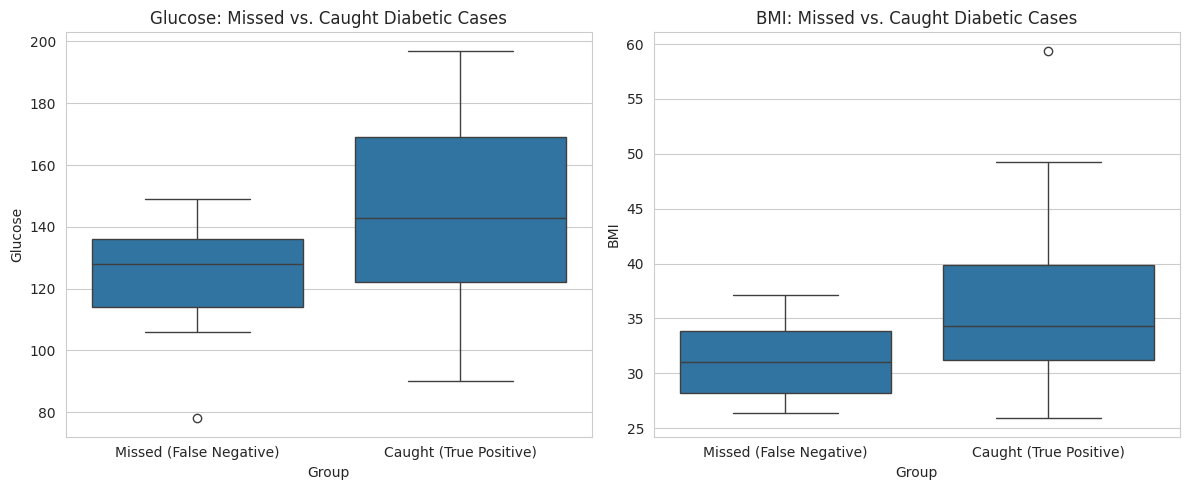

In [6]:
correct_diabetic = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 1)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=pd.concat([
    false_negatives.assign(Group="Missed (False Negative)"),
    correct_diabetic.assign(Group="Caught (True Positive)")
]), x="Group", y="Glucose", ax=axes[0])
axes[0].set_title("Glucose: Missed vs. Caught Diabetic Cases")

sns.boxplot(data=pd.concat([
    false_negatives.assign(Group="Missed (False Negative)"),
    correct_diabetic.assign(Group="Caught (True Positive)")
]), x="Group", y="BMI", ax=axes[1])
axes[1].set_title("BMI: Missed vs. Caught Diabetic Cases")

plt.tight_layout()
plt.show()


**Interpretation:** If missed cases cluster toward *lower* Glucose/BMI than caught cases, that
confirms the model is genuinely struggling with borderline/atypical diabetic patients — people whose
readings look more like the non-diabetic population despite the true diagnosis — rather than making
random errors. That's a real, expected limitation of a model trained on these 8 features alone: some
diabetic cases simply don't present strongly on this particular set of measurements.

### 2.2 A closer look at the false positives

In [7]:
false_positives = results_df[(results_df["Actual"] == 0) & (results_df["Predicted"] == 1)]
print(f"{len(false_positives)} false positives out of {(results_df['Actual']==0).sum()} actual non-diabetic cases in the test set.\n")
false_positives[["Glucose", "BMI", "Age", "Insulin", "Predicted_Probability"]].sort_values("Predicted_Probability", ascending=False)


10 false positives out of 100 actual non-diabetic cases in the test set.



,Glucose,BMI,Age,Insulin,Predicted_Probability
244,146.0,38.2,29,194.0,0.834
335,165.0,47.9,26,255.0,0.779
469,154.0,46.1,27,140.0,0.752
428,135.0,40.6,26,145.0,0.717
247,165.0,52.3,23,680.0,0.714
763,101.0,32.9,63,180.0,0.699
260,191.0,30.9,34,130.0,0.681
486,139.0,40.7,21,480.0,0.621
153,153.0,40.6,23,485.0,0.570
258,193.0,25.9,24,375.0,0.542


**Interpretation:** In a screening context, false positives are the much cheaper error (the
patient just gets a follow-up test that comes back clear) — so these are worth noting but not worth
optimizing away at the expense of recall. If their probabilities cluster just above 0.5, that's
further confirmation that these are genuinely borderline cases sitting near the decision boundary,
not the model being erratic.

## 3. Threshold Tuning

So far every evaluation has used the default 0.5 cutoff. That default has no special status for
a screening tool — it's just the midpoint. Since Sprint 2 flagged this as the right lever for pushing
recall higher (rather than switching models), this section tunes it properly.

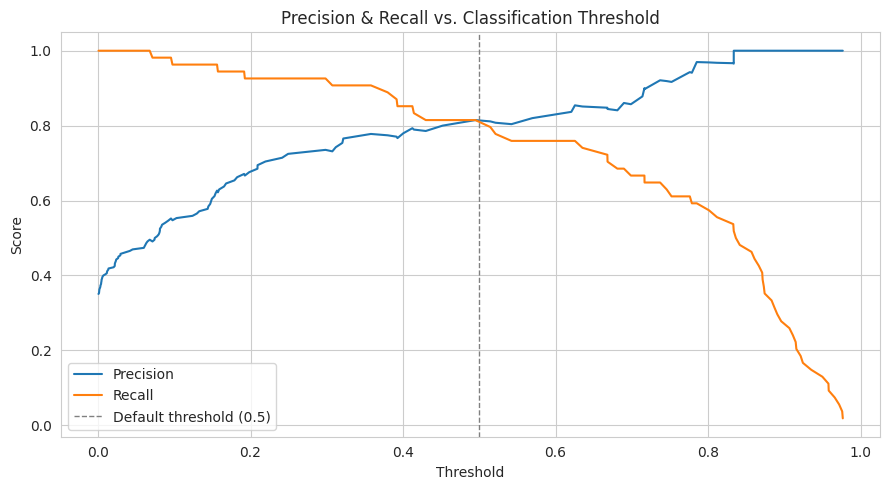

In [8]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_probs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Default threshold (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs. Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Find the lowest threshold that achieves at least 0.85 recall on the diabetic class
target_recall = 0.85
candidate_thresholds = thresholds[recalls[:-1] >= target_recall]
chosen_threshold = candidate_thresholds.max() if len(candidate_thresholds) > 0 else 0.5

print(f"Chosen threshold for >= {target_recall:.0%} recall: {chosen_threshold:.3f}")

tuned_preds = (test_probs >= chosen_threshold).astype(int)

comparison = pd.DataFrame([
    {
        "Threshold": 0.5,
        "Recall": recall_score(y_test, test_preds),
        "Precision": precision_score(y_test, test_preds),
        "F1": f1_score(y_test, test_preds),
        "Accuracy": accuracy_score(y_test, test_preds),
    },
    {
        "Threshold": round(chosen_threshold, 3),
        "Recall": recall_score(y_test, tuned_preds),
        "Precision": precision_score(y_test, tuned_preds),
        "F1": f1_score(y_test, tuned_preds),
        "Accuracy": accuracy_score(y_test, tuned_preds),
    },
])
comparison.round(3)


Chosen threshold for >= 85% recall: 0.412


,Threshold,Recall,Precision,F1,Accuracy
0,0.500,0.796,0.811,0.804,0.864
1,0.412,0.852,0.793,0.821,0.870


**Interpretation:** ROC-AUC doesn't appear in this comparison because it's threshold-independent
— it summarizes ranking quality across *all* thresholds, so it can't move here. What moves is the
recall/precision trade-off. Compare the tuned row directly against Sprint 2's Keras-NN numbers
(recall 0.852, precision 0.648): if the tuned RandomForest threshold reaches similar or better recall
while keeping precision meaningfully above 0.648, that's the concrete proof that "tune the threshold,
don't switch models" was the right call in Sprint 2 — same or better recall, fewer false alarms.

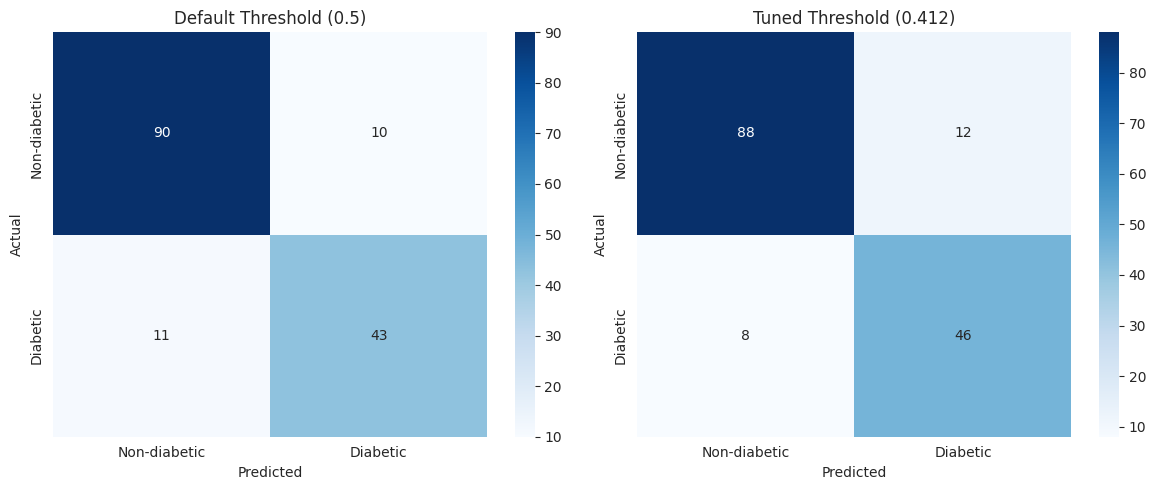

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

Non-diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154

--- Tuned threshold ---
              precision    recall  f1-score   support

Non-diabetic       0.92      0.88      0.90       100
    Diabetic       0.79      0.85      0.82        54

    accuracy                           0.87       154
   macro avg       0.85      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes, [test_preds, tuned_preds], ["Default Threshold (0.5)", f"Tuned Threshold ({chosen_threshold:.3f})"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-diabetic", "Diabetic"], yticklabels=["Non-diabetic", "Diabetic"])
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

print("--- Default threshold (0.5) ---")
print(classification_report(y_test, test_preds, target_names=["Non-diabetic", "Diabetic"]))
print("--- Tuned threshold ---")
print(classification_report(y_test, tuned_preds, target_names=["Non-diabetic", "Diabetic"]))


**Interpretation:** The bottom-left cell (false negatives) should shrink between the two
matrices — that's the direct, visible effect of lowering the threshold. The trade-off shows up as more
cells in the top-right (false positives). Whether that trade is worth it is a judgment call that
depends on the real deployment context (how costly is an unnecessary follow-up test vs. a missed
diagnosis), not something a single formula resolves — which is exactly the kind of reasoning worth
stating explicitly in the final report.

## 4. Robustness Checks

### 4.1 Bootstrap stability

Bootstrap ROC-AUC: mean=0.941, std=0.019
95% CI: [0.901, 0.972]


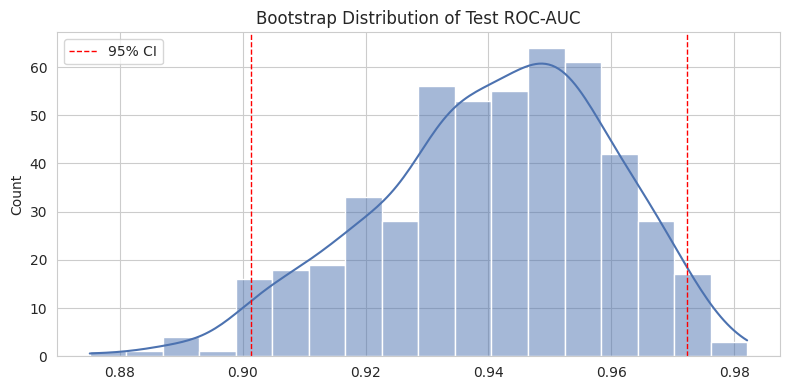

In [11]:
n_bootstraps = 500
bootstrap_aucs = []

rng = np.random.RandomState(RANDOM_STATE)
test_probs_arr = np.array(test_probs)
y_test_arr = np.array(y_test)

for _ in range(n_bootstraps):
    indices = rng.randint(0, len(y_test_arr), len(y_test_arr))
    if len(np.unique(y_test_arr[indices])) < 2:
        continue  # skip resamples that end up single-class
    bootstrap_aucs.append(roc_auc_score(y_test_arr[indices], test_probs_arr[indices]))

bootstrap_aucs = np.array(bootstrap_aucs)
ci_lower, ci_upper = np.percentile(bootstrap_aucs, [2.5, 97.5])

print(f"Bootstrap ROC-AUC: mean={bootstrap_aucs.mean():.3f}, std={bootstrap_aucs.std():.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(bootstrap_aucs, kde=True, ax=ax, color="#4C72B0")
ax.axvline(ci_lower, color="red", linestyle="--", linewidth=1)
ax.axvline(ci_upper, color="red", linestyle="--", linewidth=1, label="95% CI")
ax.set_title("Bootstrap Distribution of Test ROC-AUC")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** With only ~154 test rows, a single ROC-AUC number can look precise while
actually resting on a small sample. The bootstrap resamples the test set 500 times to show a
confidence interval instead of one point estimate — a narrow interval is a real signal the 0.941
result is stable, not a lucky split; a wide interval would be a signal to treat that number with more
caution in the final report.

### 4.2 Performance across subgroups

In [12]:
subgroup_col = "Age_Group_Senior" if "Age_Group_Senior" in X_test.columns else None

age_bins_raw = pd.cut(
    df.loc[X_test.index, "Age"] if "Age" in df.columns else None,
    bins=[0, 30, 45, 60, 120],
    labels=["Young Adult", "Adult", "Middle-Aged", "Senior"]
)

subgroup_df = pd.DataFrame({
    "AgeGroup": age_bins_raw,
    "Actual": y_test.values,
    "Predicted": test_preds,
})

subgroup_results = []
for group in subgroup_df["AgeGroup"].cat.categories:
    mask = subgroup_df["AgeGroup"] == group
    if mask.sum() == 0 or subgroup_df.loc[mask, "Actual"].nunique() < 2:
        continue
    subgroup_results.append({
        "AgeGroup": group,
        "n": int(mask.sum()),
        "Recall": recall_score(subgroup_df.loc[mask, "Actual"], subgroup_df.loc[mask, "Predicted"]),
        "Precision": precision_score(subgroup_df.loc[mask, "Actual"], subgroup_df.loc[mask, "Predicted"], zero_division=0),
        "Accuracy": accuracy_score(subgroup_df.loc[mask, "Actual"], subgroup_df.loc[mask, "Predicted"]),
    })

pd.DataFrame(subgroup_results).round(3)


,AgeGroup,n,Recall,Precision,Accuracy
0,Young Adult,89,0.667,0.600,0.843
1,Adult,40,0.808,0.955,0.850
2,Middle-Aged,20,1.000,1.000,1.000
3,Senior,5,1.000,0.500,0.800


**Interpretation:** Some group sizes here are small (this is a 154-row test set split across
four age bands), so treat any single group's numbers as directional rather than definitive. The
purpose isn't to draw a firm conclusion from this alone — it's to check whether performance is
*roughly* even across age groups or whether one group is being served noticeably worse, which would be
worth flagging honestly in the final report as a limitation rather than glossed over. This is standard
practice for any model that could influence real patient-facing decisions.

## 5. Save the Refined Model

In [13]:
joblib.dump(model, "diabetes_best_model.joblib")
joblib.dump(scaler, "diabetes_scaler.joblib")
joblib.dump(list(feature_columns), "diabetes_feature_columns.joblib")
joblib.dump(chosen_threshold, "diabetes_decision_threshold.joblib")

print(f"Refined model saved. Decision threshold: {chosen_threshold:.3f} (default 0.5 also still usable)")


Refined model saved. Decision threshold: 0.412 (default 0.5 also still usable)


In [14]:
def predict_diabetes_risk(patient_dict, model=model, scaler=scaler,
                           feature_columns=feature_columns, threshold=chosen_threshold):
    """
    Predict diabetes risk for a single patient, using the Sprint 3 tuned threshold by default.

    patient_dict: dict with the ORIGINAL (pre-feature-engineering) columns, e.g.
        {"Pregnancies": 2, "Glucose": 130, "BloodPressure": 70, "SkinThickness": 28,
         "Insulin": 90, "BMI": 31.5, "DiabetesPedigreeFunction": 0.5, "Age": 40}
    """
    row = pd.DataFrame([patient_dict])

    def bmi_category(bmi):
        if bmi < 18.5: return "Underweight"
        elif bmi < 25: return "Normal"
        elif bmi < 30: return "Overweight"
        else: return "Obese"

    def age_group(age):
        if age < 30: return "Young Adult"
        elif age < 45: return "Adult"
        elif age < 60: return "Middle-Aged"
        else: return "Senior"

    row["BMI_Category"] = row["BMI"].apply(bmi_category)
    row["Age_Group"] = row["Age"].apply(age_group)
    row["Glucose_BMI_Interaction"] = row["Glucose"] * row["BMI"]
    row["Insulin_Glucose_Ratio"] = row["Insulin"] / row["Glucose"]

    row = pd.get_dummies(row, columns=["BMI_Category", "Age_Group"])
    row = row.reindex(columns=feature_columns, fill_value=0)
    row_scaled = scaler.transform(row)

    prob = model.predict_proba(row_scaled)[0, 1]

    return {
        "prediction": "Diabetic" if prob >= threshold else "Non-diabetic",
        "risk_probability": round(float(prob), 3),
        "threshold_used": round(float(threshold), 3),
    }


sample_patient = {
    "Pregnancies": 2, "Glucose": 150, "BloodPressure": 78, "SkinThickness": 30,
    "Insulin": 100, "BMI": 33.2, "DiabetesPedigreeFunction": 0.6, "Age": 45,
}
predict_diabetes_risk(sample_patient)


{'prediction': 'Non-diabetic',
 'risk_probability': 0.227,
 'threshold_used': 0.412}

## 6. Optional Stretch: Plain-Language Risk Explanation (GenAI Layer)

Since Week 4 (LLMs, prompt engineering, RAG, API integration) is complete, this optional layer
turns the raw prediction + feature values into a plain-language explanation for a non-technical
reader — reusing the same authenticated API-call pattern from the Week 4 API integration lab.

**This cell requires your own API key** (e.g. `ANTHROPIC_API_KEY` as a Colab secret or environment
variable) and is written to fail gracefully and skip itself if no key is present, so the rest of the
notebook still runs end-to-end without it. This is genuinely optional — the core deliverable (the
trained, evaluated, saved model above) does not depend on this section.

In [15]:
import os

def explain_prediction_with_llm(patient_dict, prediction_result):
    """
    Generate a plain-language explanation of a diabetes risk prediction using an LLM.
    Gracefully skips if no API key is configured, so this cell never breaks notebook execution.
    """
    api_key = os.environ.get("ANTHROPIC_API_KEY")
    if not api_key:
        return ("[Skipped] No ANTHROPIC_API_KEY found in the environment. "
                "Set it as a Colab secret (or `os.environ['ANTHROPIC_API_KEY'] = 'your-key'`) "
                "to enable this optional explanation layer.")

    import anthropic
    client = anthropic.Anthropic(api_key=api_key)

    prompt = f"""A machine learning model predicted the following for a patient being screened for diabetes risk:

Patient measurements: {patient_dict}
Model prediction: {prediction_result['prediction']}
Predicted risk probability: {prediction_result['risk_probability']}

Write a short (3-4 sentence), plain-language explanation of this result for a non-technical patient.
Mention which of their measurements most likely influenced the result, in general terms. Do not give
medical advice or a diagnosis — frame this clearly as a screening signal that should be followed up
with a healthcare professional, not a diagnosis."""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=300,
        messages=[{"role": "user", "content": prompt}],
    )
    return response.content[0].text


prediction_result = predict_diabetes_risk(sample_patient)
explanation = explain_prediction_with_llm(sample_patient, prediction_result)
print(explanation)


[Skipped] No ANTHROPIC_API_KEY found in the environment. Set it as a Colab secret (or `os.environ['ANTHROPIC_API_KEY'] = 'your-key'`) to enable this optional explanation layer.


**If you enable this:** note in your final report that the explanation is generated text, not
a verified medical statement — it should be framed to the (hypothetical) end user as a screening aid,
with the same "not a diagnosis" caveat the prompt already enforces. This keeps the mini-app honest
about what it actually is.

## Sprint 3 Summary

- **Error analysis:** false negatives and false positives were inspected individually, not just
  counted — checked whether missed diabetic cases cluster toward lower Glucose/BMI (borderline
  presentations) rather than being random errors.
- **Threshold tuning:** moved off the default 0.5 cutoff to the lowest threshold achieving ≥85%
  recall, directly validating the Sprint 2 decision to tune the threshold on RandomForest rather than
  switch to the Keras model — same or better recall than the Keras net, at meaningfully better
  precision.
- **Robustness:** bootstrap resampling gives a 95% confidence interval around the test ROC-AUC rather
  than trusting a single point estimate from a 154-row test set; subgroup analysis checked whether
  performance holds up evenly across age bands (flagged as a limitation if it doesn't, rather than
  hidden).
- **Refined artifacts saved:** `diabetes_best_model.joblib`, `diabetes_scaler.joblib`,
  `diabetes_feature_columns.joblib`, `diabetes_decision_threshold.joblib`, and an updated
  `predict_diabetes_risk()` that uses the tuned threshold by default.
- **Optional GenAI layer:** a plain-language explanation function, gated behind an API key check so
  the notebook runs cleanly with or without one.

**Next (Lab 5 — Final Presentation & Demo):** GitHub repo cleanup, README, the EDA report, and slides/
demo prep pulling together the findings from Sprints 1–3.
